## Import delle librerie

In [47]:
# Manipolazione dati
import pandas as pd
import numpy as np

# Visualizzazione (se necessaria per controlli)
import matplotlib.pyplot as plt
import seaborn as sns

# Modellazione
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

## Caricamento del dataset


In [48]:
df = pd.read_csv('../data/raw/telco_customer_churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Quality Checks

Prima di procedere con la preparazione dei dati per la modellazione, è necessario verificare la presenza di eventuali criticità tecniche, come valori mancanti o formati non coerenti.

In [49]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Verifica dati duplicati e di tipo

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df['customerID'].nunique()

7043

Verificata l’assenza/presenza di duplicati sia a livello di riga completa sia a livello di identificativo che univoco

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [53]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [54]:
df.loc[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull(), 'TotalCharges'].unique()

array([' '], dtype=object)

In [55]:
(df[df['TotalCharges'] == ' '].shape[0])

11

In [56]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'].dtype

dtype('float64')

Individuata un’incongruenza nel tipo di dato di `TotalCharges` non coerente con variabile quantitativa; tramite conversione controllata è stata verificata la presenza di valori non numerici (stringhe vuote), successivamente sostituiti con il valore `NaN` e infine la colonna è stata convertita a tipo numerico.

## Data Preparation

Conclusa la fase di Data Quality Checks, si procede con la preparazione dei dati in vista del modeling. In questa sezione verranno gestiti i valori mancanti e definite le feature utilizzabili per la costruzione del modello.

### Gestione valori nulli

In [57]:
df.loc[df['TotalCharges'].isna(), ['tenure', 'MonthlyCharges']]

,tenure,MonthlyCharges
488,0,52.55
753,0,20.25
936,0,80.85
1082,0,25.75
1340,0,56.05
3331,0,19.85
3826,0,25.35
4380,0,20.00
5218,0,19.70
6670,0,73.35


In [58]:
(df['TotalCharges'] - df['MonthlyCharges'] * df['tenure']).abs().describe()

count    7032.000000
mean       45.089157
std        49.899711
min         0.000000
25%         9.437500
50%        28.650000
75%        63.700000
max       373.250000
dtype: float64

Dall’analisi è emerso che i valori mancanti in `TotalCharges` sono correlati ai clienti con `tenure = 0`, presumendo che il totale non sia ancora conteggiato. Inoltre, è stato verificato che `TotalCharges` non coincide in generale con `MonthlyCharges × tenure`, indicando che il totale cumulato riflette dinamiche storiche (es. variazioni di piano o costi aggiuntivi) e non solo il prezzo mensile corrente.

In [59]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Poiché il totale cumulato `TotalCharges` non può essere diverso da 0 in assenza di mesi di permanenza, i `NaN` sono stati sostituiti con 0 per coerenza logica.

### Definizione target e strategica delle feature

In questa fase identifichiamo il target e separiamo le variabili di input distinguendo tra feature numeriche e categoriche, escludendo eventuali identificativi per preparare correttamente il dataset al modeling.

In [60]:
target = 'Churn'
df_model = df.drop(columns=['customerID'])

Definita la variabile target ed escluso l’identificatore univoco, in quanto privo di valore predittivo per il modello.

In [61]:
features_num = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
features_cat = df_model.drop(columns=features_num + [target]).columns.tolist()

Sono state identificate e classificate le feature numeriche e categoriche; si procediamo ora alla definizione della matrice delle feature (X) e della variabile target (y) per il modeling.

In [62]:
X_features = df_model.drop(columns=target)
y_target = df_model[target]

#### Conversione Churn

La variabile target `Churn` viene convertita in formato numerico binario (0/1) per garantire coerenza con gli algoritmi di classificazione e facilitare l’interpretazione delle metriche.

In [63]:
y_target = y_target.map({"Yes": 1, "No": 0})

### Output dataset pulito

Al termine della Data Preparation viene salvata una versione “clean” del dataset in `data/processed/`, contenente esclusivamente trasformazioni deterministiche (fix tipi e gestione missing), mantenendo il raw immutato.

In [64]:
df_clean = df_model.copy()
df_clean.to_csv('../data/processed/telco_clean.csv', index=False)

## Modeling Setup

Conclusa la fase di Data Preparation, si procede alla configurazione del modeling. In questa sezione verrà definita la strategia di train/test split coerente con il task di classificazione e impostato il preprocessing necessario, mantenendo separazione rigorosa tra dati di training e dati di test per evitare leakage.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42, stratify=y_target)

Eseguito train/test split stratificato su `y_target` per mantenere proporzioni coerenti della classe target tra training e test set.

In [66]:
y_target.value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

La distribuzione della variabile target evidenzia uno sbilanciamento; per mantenere proporzioni coerenti tra training e test set è stato utilizzato uno split stratificato(stratify).

### Preprocessing delle feature

In questa fase vengono applicate le trasformazioni necessarie alle feature prima dell’addestramento del modello.  
Le variabili numeriche vengono standardizzate tramite `StandardScaler`, mentre le variabili categoriche vengono trasformate tramite `OneHotEncoder`.  
Tutte le trasformazioni vengono fittate esclusivamente sul training set e successivamente applicate al test set per evitare data leakage, mantenendo la separazione tra dati di addestramento e dati di valutazione.

#### Contenitori vuoti

In [67]:
df_X_train_preprocessed = pd.DataFrame(index=X_train.index)
df_X_test_preprocessed = pd.DataFrame(index=X_test.index)

#### Feature numeriche

In [68]:
ss = StandardScaler()
X_train_std = ss.fit_transform(X_train[features_num])
X_test_std = ss.transform(X_test[features_num])
num_features_names = ss.get_feature_names_out(features_num)

df_X_train_preprocessed[num_features_names] = X_train_std
df_X_test_preprocessed[num_features_names] = X_test_std

#### Feature categoriche

In [69]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# Note: handle_unknown="ignore" è impostato per garantire coerenza nel caso in cui il test set contenga categorie non presenti nel training set.
X_train_ohe = encoder.fit_transform(X_train[features_cat])
X_test_ohe = encoder.transform(X_test[features_cat])
cat_feature_names = encoder.get_feature_names_out(features_cat)

df_X_train_preprocessed[cat_feature_names] = X_train_ohe
df_X_test_preprocessed[cat_feature_names] = X_test_ohe

## Baseline Model

In questa fase costruiamo un modello baseline interpretabile per stabilire un primo riferimento quantitativo delle performance.  
L’obiettivo non è massimizzare subito l’accuratezza, ma ottenere una valutazione iniziale coerente con il task di classificazione e utile come termine di confronto per eventuali miglioramenti successivi.

### Logistic Regression Model

Viene addestrato un modello di Logistic Regression come baseline interpretabile.  
Le performance vengono valutate considerando sia l’accuracy complessiva sia il recall della classe positiva (Churn = 1), in quanto la mancata identificazione di un cliente a rischio rappresenta il costo principale per il business.

#### Addestramento del modello

In [70]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(df_X_train_preprocessed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Predizioni su test set

In [71]:
y_pred = log_reg.predict(df_X_test_preprocessed)

#### Metriche

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Accuracy test: {accuracy:.4f}')
print(f'Precision test: {precision:.4f}')
print(f'Recall test: {recall:.4f}')

Accuracy test: 0.8055
Precision test: 0.6572
Recall test: 0.5588


In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



##### Confusion Matrix

In assenza di informazioni quantitative sui costi aziendali, si assume che la perdita di un cliente (falso negativo) abbia un impatto economico maggiore rispetto al costo di un falso positivo (intervento di retention non necessario). 

Pertanto, nella valutazione del modello baseline viene posta particolare attenzione al recall della classe positiva (Churn = 1).

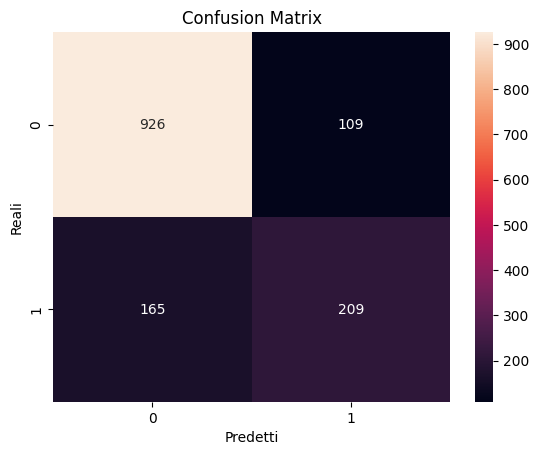

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predetti")
plt.ylabel("Reali")
plt.title("Confusion Matrix")
plt.show()

### Conclusione Baseline

Il modello di Logistic Regression ottiene un’accuracy pari a 0.80, superiore alla proporzione della classe maggioritaria nel dataset(No=73%). Tuttavia, il recall della classe positiva (0.56) evidenzia che una parte rilevante dei clienti a rischio non viene intercettata.

Il modello baseline rappresenta quindi un punto di riferimento valido, ma migliorabile in ottica di riduzione dei falsi negativi.